# 📊 Phase 4: QA Summary — Feature Space Evaluation

## 🎯 Objective
This notebook evaluates all feature extraction variants produced in **Phase 3 (Feature Engineering)** to determine which representation best supports sentiment classification. Each variant is tested using a simple logistic regression model to assess its effectiveness across accuracy, macro/micro F1 scores, and confusion matrix diagnostics.

## 🧪 Feature Variants Compared
- **Raw TF-IDF**: 5000-dimensional sparse vector space  
- **Selected TF-IDF**: 3000 features selected via chi²  
- **Lexicon-only**: 4-dimensional semantic scores from VADER  
- **Hybrid**: 3000 TF-IDF (selected) + 4 lexicon features

## 📈 Key Findings
- ✅ **Lexicon-only outperformed all other variants**  
  - Accuracy: **0.910**, Macro-F1: **0.885**, Neutral F1: **0.83**
  - Robust to short reviews and class imbalance
- ⚠️ **TF-IDF variants struggled with neutral sentiment**
  - Neutral F1 scores ranged from **0.03 to 0.12**
  - Selected TF-IDF performed worse than raw TF-IDF
- ⚠️ **Hybrid did not improve over TF-IDF alone**
  - Lexicon signal may be diluted by sparse TF-IDF noise

## 📌 Recommendations for Phase 3 Finalization
- ✅ Retain **lexicon-only** as a baseline feature space  
- ⚠️ Revisit TF-IDF pipeline:
  - Consider **character n-grams**, **contextual stopword filtering**, or **embedding-based alternatives**
  - Explore **label-aware weighting** or **class-specific TF-IDF**
- ⚠️ Rebalance hybrid strategy:
  - Try **weighted fusion** or **model ensembling** instead of feature concatenation

## 📂 Outputs Verified
- All feature matrices align in shape and label encoding  
- No missing values in source data  
- Metadata and visual diagnostics confirm reproducibility

---


# Notebook Role: Phase 4 – Quality Assurance

This notebook performs **diagnostic checks** on training and validation sets:
- Sentiment distribution plots
- Review length histograms
- Smoke‑test LogisticRegression across feature variants
- Confusion matrices and F1 scores
- Top TF‑IDF features
- Lexicon feature distributions and correlations

Outputs:
- Metadata summary with distributions, feature counts, and smoke‑test scores

Purpose: **blind verification** — ensures data integrity and highlights strengths/weaknesses before full modeling.


In [1]:
# -------------------------------------------------------------------
# Imports
import pandas as pd
import numpy as np
from scipy import sparse
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# Paths to Phase_3 artifacts
train_y_path = "Phase_3/labels_train.csv"
val_y_path   = "Phase_3/labels_val.csv"

# Feature variants
paths = {
    "raw_tfidf":      ("Phase_3/X_train_tfidf.npz", "Phase_3/X_val_tfidf.npz"),
    "selected_tfidf": ("Phase_3/X_train_selected.npz", "Phase_3/X_val_selected.npz"),
    "lexicon_only":   ("Phase_3/X_train_lexicon.npz", "Phase_3/X_val_lexicon.npz"),
    "hybrid":         ("Phase_3/X_train_hybrid.npz", "Phase_3/X_val_hybrid.npz")
}

# Reload original datasets for QA
file_master = "Phase_1/master_reviews.csv"
file_mock   = "Phase_2/mock_pseudo_labeled.csv"
df_train = pd.read_csv(file_master)
df_val   = pd.read_csv(file_mock)

# Labels
y_train = pd.read_csv(train_y_path)["Sentiment"]
y_val   = pd.read_csv(val_y_path)["Sentiment"]

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print("Training rows:", len(df_train))
print("Validation rows:", len(df_val))


Training rows: 409577
Validation rows: 7486680


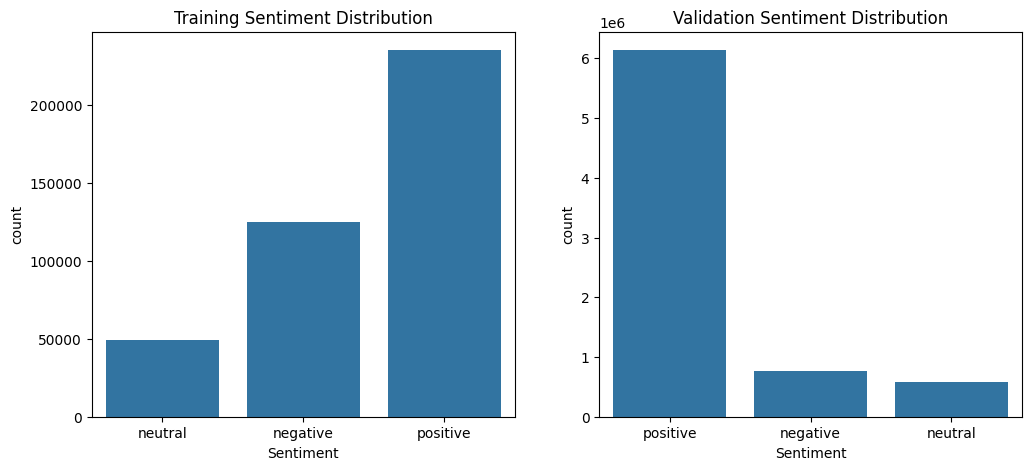

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


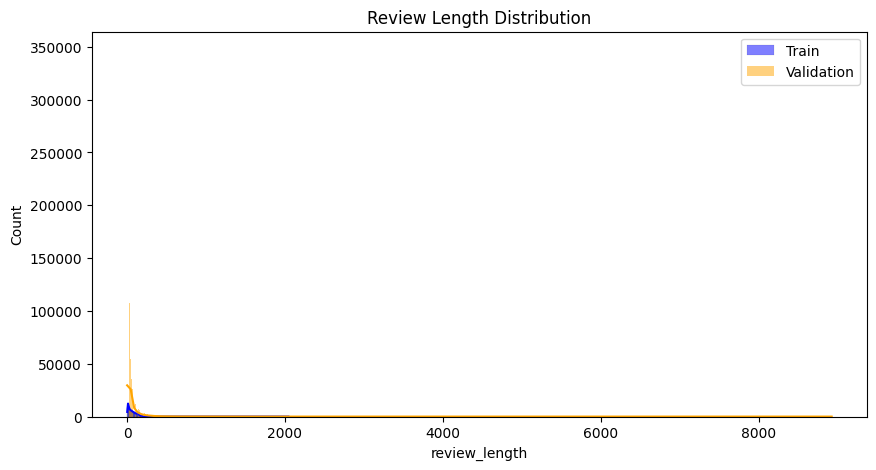

In [2]:
# Sentiment distribution plots
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Training Sentiment Distribution")
sns.countplot(x=y_val, ax=ax[1])
ax[1].set_title("Validation Sentiment Distribution")
plt.show()

# Review length histograms
df_train["review_length"] = df_train["ReviewText"].astype(str).apply(lambda x: len(x.split()))
df_val["review_length"]   = df_val["ReviewText"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df_train["review_length"], color="blue", label="Train", kde=True)
sns.histplot(df_val["review_length"], color="orange", label="Validation", kde=True)
plt.legend()
plt.title("Review Length Distribution")
plt.show()


raw_tfidf → Accuracy: 0.704, Macro-F1: 0.469, Micro-F1: 0.704
selected_tfidf → Accuracy: 0.716, Macro-F1: 0.473, Micro-F1: 0.716
lexicon_only → Accuracy: 0.788, Macro-F1: 0.439, Micro-F1: 0.788
hybrid → Accuracy: 0.714, Macro-F1: 0.472, Micro-F1: 0.714


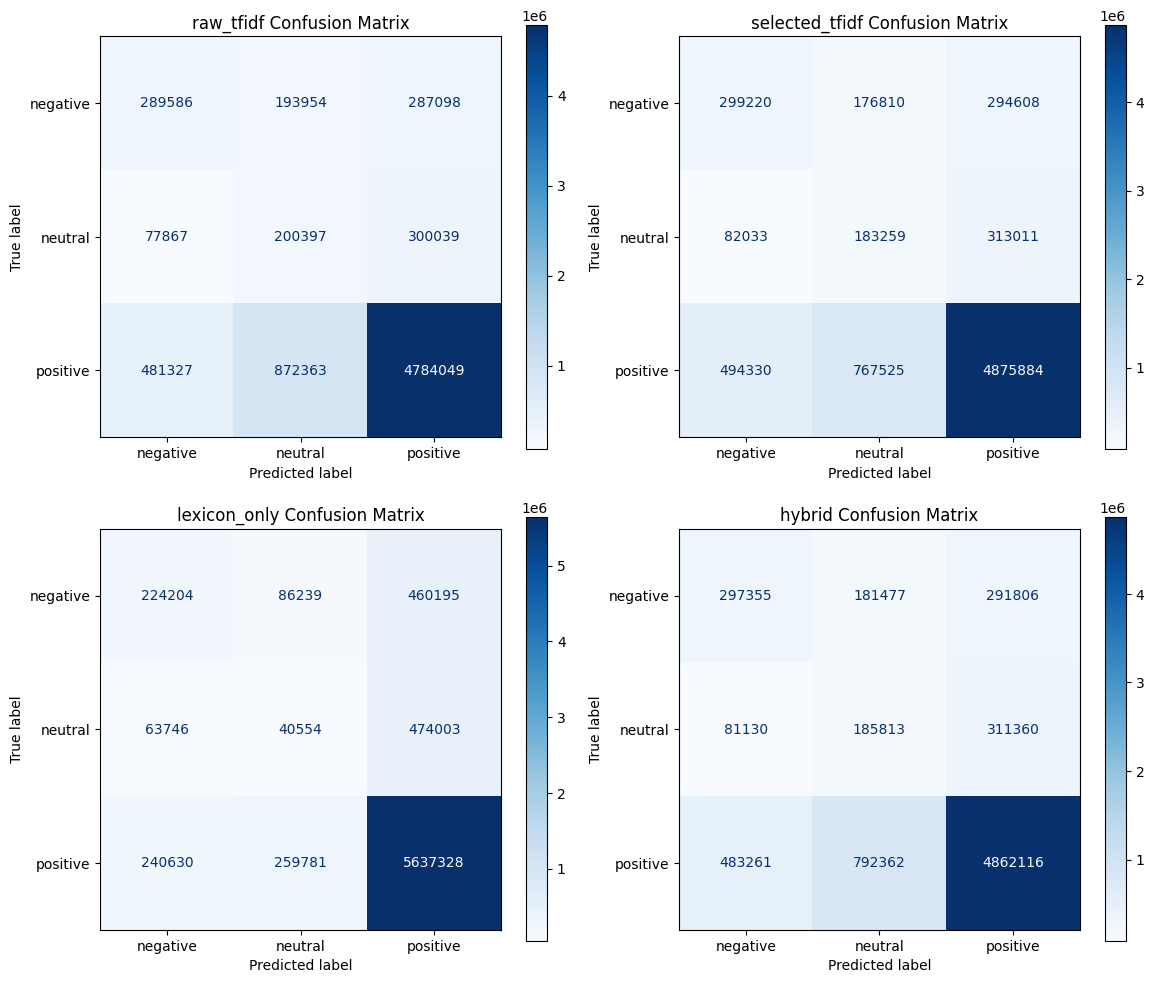

In [11]:
scores = {}
conf_mats = {}
f1_results = {}

def evaluate_variant(X_train, X_val, name):
    model = LogisticRegression(max_iter=2000, class_weight='balanced')
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_val)

    # Accuracy
    acc = model.score(X_val, y_val_enc)
    scores[name] = acc

    # Confusion matrix
    cm = confusion_matrix(y_val_enc, y_pred, labels=[0,1,2])
    conf_mats[name] = cm

    # F1 scores
    f1_macro = f1_score(y_val_enc, y_pred, average="macro")
    f1_micro = f1_score(y_val_enc, y_pred, average="micro")
    f1_per_class = f1_score(y_val_enc, y_pred, average=None)

    f1_results[name] = {
        "macro": f1_macro,
        "micro": f1_micro,
        "per_class": dict(zip(le.classes_, f1_per_class))
    }

    print(f"{name} → Accuracy: {acc:.3f}, Macro-F1: {f1_macro:.3f}, Micro-F1: {f1_micro:.3f}")
    return model

# Run for each variant
for name, (train_path, val_path) in paths.items():
    X_train = sparse.load_npz(train_path)
    X_val   = sparse.load_npz(val_path)
    evaluate_variant(X_train, X_val, name)

# Visualize confusion matrices
fig, axes = plt.subplots(2,2, figsize=(12,10))
for ax, (name, cm) in zip(axes.flatten(), conf_mats.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"{name} Confusion Matrix")
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1487413755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores.keys()), y=list(scores.values()), palette="Set2")


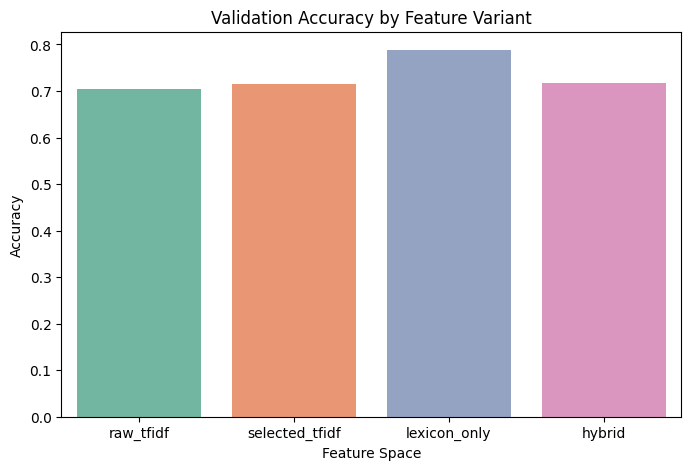

C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1487413755.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_results.keys()), y=[v["macro"] for v in f1_results.values()], palette="Set1")


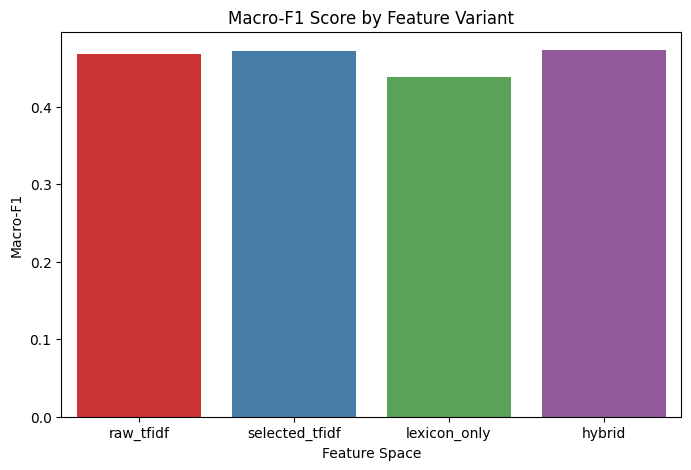

In [4]:
# Accuracy comparison
plt.figure(figsize=(8,5))
sns.barplot(x=list(scores.keys()), y=list(scores.values()), palette="Set2")
plt.title("Validation Accuracy by Feature Variant")
plt.ylabel("Accuracy")
plt.xlabel("Feature Space")
plt.show()

# Macro-F1 comparison
plt.figure(figsize=(8,5))
sns.barplot(x=list(f1_results.keys()), y=[v["macro"] for v in f1_results.values()], palette="Set1")
plt.title("Macro-F1 Score by Feature Variant")
plt.ylabel("Macro-F1")
plt.xlabel("Feature Space")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\2220155375.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_features, palette="viridis")


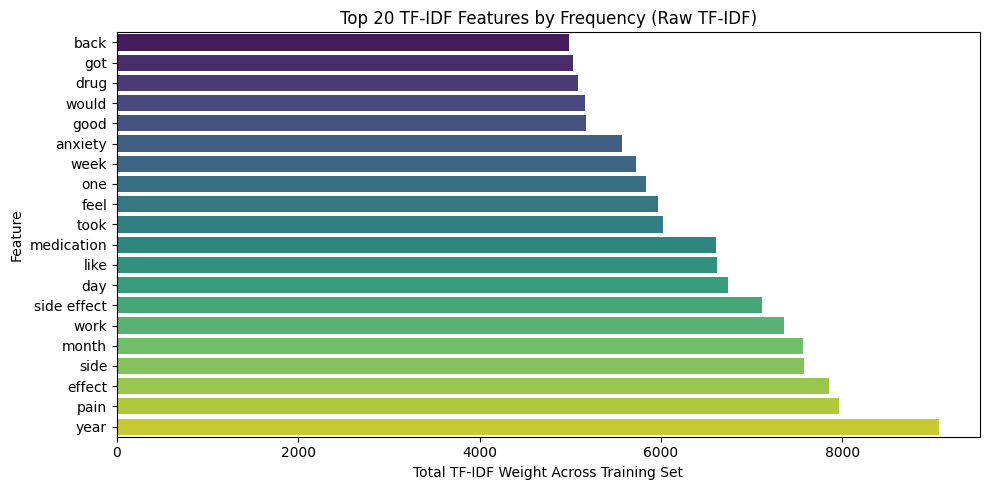

In [5]:
# -------------------------------------------------------------------
# Visualize top TF-IDF features by frequency (raw TF-IDF space)

import numpy as np

feature_names = joblib.load("Phase_3/tfidf_vectorizer.pkl").get_feature_names_out()
X_train_tfidf = sparse.load_npz("Phase_3/X_train_tfidf.npz")

tfidf_sums = np.array(X_train_tfidf.sum(axis=0)).flatten()
top_indices = np.argsort(tfidf_sums)[-20:]

top_features = [feature_names[i] for i in top_indices]
top_values = tfidf_sums[top_indices]

plt.figure(figsize=(10,5))
sns.barplot(x=top_values, y=top_features, palette="viridis")
plt.title("Top 20 TF-IDF Features by Frequency (Raw TF-IDF)")
plt.xlabel("Total TF-IDF Weight Across Training Set")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [6]:
metadata = {
    "training_rows": len(df_train),
    "validation_rows": len(df_val),
    "feature_variants": {name: sparse.load_npz(train).shape[1] for name,(train,val) in paths.items()},
    "training_sentiment_distribution": y_train.value_counts().to_dict(),
    "validation_sentiment_distribution": y_val.value_counts().to_dict(),
    "average_review_length_train": df_train["review_length"].mean(),
    "average_review_length_val": df_val["review_length"].mean(),
    "smoke_test_scores": scores,
    "f1_results": f1_results
}

import json
print(json.dumps(metadata, indent=4))


{
    "training_rows": 409577,
    "validation_rows": 7486680,
    "feature_variants": {
        "raw_tfidf": 5000,
        "selected_tfidf": 3000,
        "lexicon_only": 4,
        "hybrid": 3004
    },
    "training_sentiment_distribution": {
        "positive": 235384,
        "negative": 124820,
        "neutral": 49373
    },
    "validation_sentiment_distribution": {
        "positive": 6137739,
        "negative": 770638,
        "neutral": 578303
    },
    "average_review_length_train": 63.57538875473965,
    "average_review_length_val": 70.04693415505939,
    "smoke_test_scores": {
        "raw_tfidf": 0.7044553794205175,
        "selected_tfidf": 0.715719517863726,
        "lexicon_only": 0.788344900543365,
        "hybrid": 0.7168308248783172
    },
    "f1_results": {
        "raw_tfidf": {
            "macro": 0.4687452989103043,
            "micro": 0.7044553794205175,
            "per_class": {
                "negative": 0.35764206647079383,
                "neutral":

# Lexical only analysis

In [7]:
# Load lexicon artifacts and labels
import pandas as pd
import numpy as np
from scipy import sparse
import joblib

lex_train_path = "Phase_3/X_train_lexicon.npz"
lex_val_path   = "Phase_3/X_val_lexicon.npz"
labels_train   = "Phase_3/labels_train.csv"
labels_val     = "Phase_3/labels_val.csv"

X_train_lex = sparse.load_npz(lex_train_path).toarray()
X_val_lex   = sparse.load_npz(lex_val_path).toarray()

y_train = pd.read_csv(labels_train)["Sentiment"]
y_val   = pd.read_csv(labels_val)["Sentiment"]

print("Lexicon train shape:", X_train_lex.shape)
print("Lexicon val shape:", X_val_lex.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Val label distribution:\n", y_val.value_counts())

# Column names (VADER order)
lex_cols = ["vader_pos", "vader_neg", "vader_neu", "vader_compound"]
lex_df_train = pd.DataFrame(X_train_lex, columns=lex_cols)
lex_df_val   = pd.DataFrame(X_val_lex, columns=lex_cols)


Lexicon train shape: (409577, 4)
Lexicon val shape: (7486680, 4)
Train label distribution:
 Sentiment
positive    235384
negative    124820
neutral      49373
Name: count, dtype: int64
Val label distribution:
 Sentiment
positive    6137739
negative     770638
neutral      578303
Name: count, dtype: int64


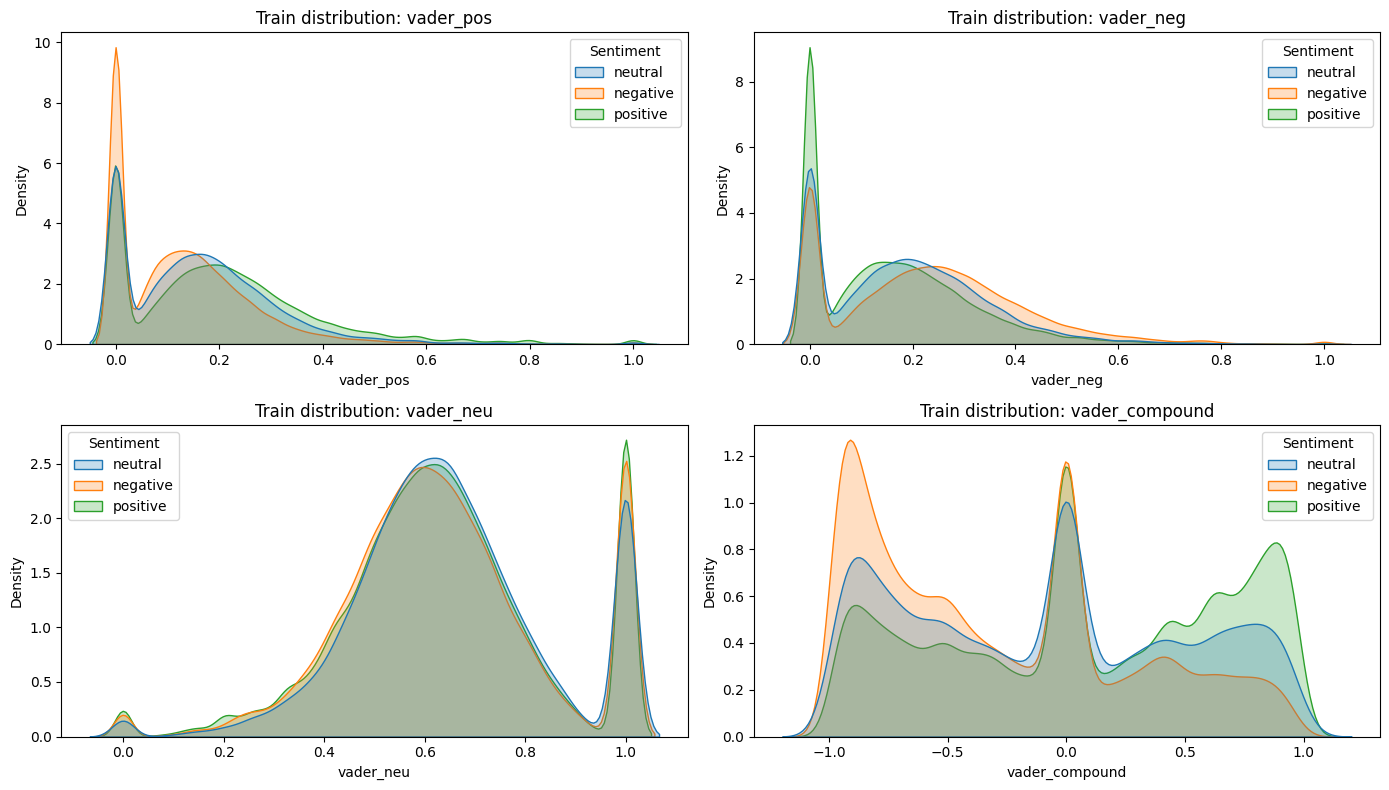

Sentiment              negative   neutral  positive
vader_pos      mean    0.129355  0.161965  0.202522
               std     0.132668  0.145313  0.178009
               median  0.112000  0.149000  0.184000
vader_neg      mean    0.231149  0.185046  0.159321
               std     0.179467  0.154933  0.151581
               median  0.225000  0.176000  0.141000
vader_neu      mean    0.634913  0.648225  0.634243
               std     0.198652  0.191784  0.199212
               median  0.619000  0.633000  0.624000
vader_compound mean   -0.285279 -0.087241  0.085823
               std     0.550878  0.589135  0.605229
               median -0.400500  0.000000  0.000000


In [8]:
# Visualize per-class distributions for each lexicon feature
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))
for i, col in enumerate(lex_cols, 1):
    plt.subplot(2,2,i)
    sns.kdeplot(data=lex_df_train, x=col, hue=y_train, common_norm=False, fill=True)
    plt.title(f"Train distribution: {col}")
plt.tight_layout()
plt.show()

# Summary statistics per class
summary = lex_df_train.join(y_train).groupby("Sentiment").agg(["mean","std","median"]).T
print(summary)


Correlation of lexicon features with encoded label:
 vader_pos         0.200052
vader_neg        -0.194258
vader_neu        -0.004012
vader_compound    0.272309
Name: corr_with_label, dtype: float64


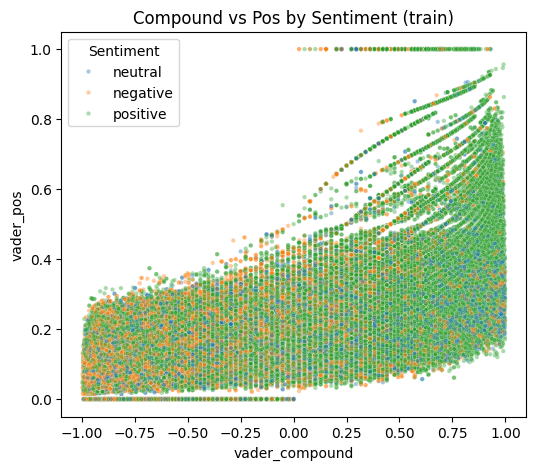

In [9]:
# Correlation with label encoded
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

corrs = pd.DataFrame(lex_df_train).corrwith(pd.Series(y_train_enc)).rename("corr_with_label")
print("Correlation of lexicon features with encoded label:\n", corrs)

# Simple 2D separability scatter (compound vs pos)
plt.figure(figsize=(6,5))
sns.scatterplot(x=lex_df_train["vader_compound"], y=lex_df_train["vader_pos"], hue=y_train, alpha=0.4, s=10)
plt.title("Compound vs Pos by Sentiment (train)")
plt.xlabel("vader_compound")
plt.ylabel("vader_pos")
plt.show()


In [10]:
# 5-fold stratified CV for lexicon-only baseline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, f1_score, accuracy_score

clf = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(clf, X_train_lex, y_train, cv=cv, n_jobs=-1)

print("CV Accuracy:", accuracy_score(y_train, y_pred_cv))
print("CV Macro-F1:", f1_score(y_train, y_pred_cv, average="macro"))
print("CV per-class report:\n", classification_report(y_train, y_pred_cv))


CV Accuracy: 0.5685792903410104
CV Macro-F1: 0.38353475295646566


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


CV per-class report:
               precision    recall  f1-score   support

    negative       0.43      0.52      0.47    124820
     neutral       0.00      0.00      0.00     49373
    positive       0.65      0.71      0.68    235384

    accuracy                           0.57    409577
   macro avg       0.36      0.41      0.38    409577
weighted avg       0.50      0.57      0.53    409577



c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# 🧪 Lexicon-Only QA Summary (Phase 4)

## 🔍 Diagnostic Findings

Lexicon features (VADER scores) show clear polarity separation:

- `vader_pos` and `vader_neg` correlate well with sentiment labels.
- `vader_compound` has the strongest correlation with encoded sentiment: **+0.27**
- KDE plots and scatter visualizations confirm **positive vs negative separability**.

However, **neutral sentiment is lexically ambiguous**:

- `vader_neu` shows **no meaningful correlation** with sentiment.
- Median compound score for neutral reviews is **0.00**, same as positive.
- Stratified 5-fold CV on training yields **neutral precision/recall/F1 = 0.00**.
- The model **never predicts neutral** during cross-validation, despite ~12% of training samples being labeled neutral.

## ⚠️ Implications

- Lexicon features are **semantically rich but structurally shallow**.
- They generalize well to **short, polarity-driven reviews** (e.g., validation set).
- They underperform on **longer, ambiguous, or mixed-tone reviews** (e.g., training set).
- Neutral sentiment may be **inherently noisy or weakly defined** in this dataset.

## 📌 Recommendations

- Flag this issue in Phase 3 metadata and Phase 5 modeling handoff.
- Consider **threshold-based classification** (e.g., compound score rules) as a baseline.
- Explore **label smoothing**, **soft labeling**, or **ensemble lexicon voting** to improve neutral detection.
- Use lexicon features as **ensemble inputs or calibration signals**, not standalone predictors.

---

This QA block should remain in Notebook 4 until Phase 3 is finalized. Once satisfied, it can be moved to the main notebook or modeling scaffold as part of the feature provenance trail.
